# Aula 3 - Segmentação semântica de imagens

Até agora, você viu a classificação de imagens, em que a tarefa da rede é atribuir um rótulo ou classe a uma imagem de entrada. No entanto, suponha que você queira saber onde um objeto está localizado na imagem, a forma desse objeto, qual pixel pertence a qual objeto etc. Nesse caso, você desejará segmentar a imagem, ou seja, para cada pixel da imagem é dado um rótulo. Assim, a tarefa da segmentação de imagens é treinar uma rede neural para produzir uma máscara da imagem em pixels. Isso ajuda a entender a imagem em um nível muito mais baixo, isto é, o nível de pixel. A segmentação de imagens tem muitas aplicações em imagens médicas, carros autônomos e imagens de satélite, para citar alguns.

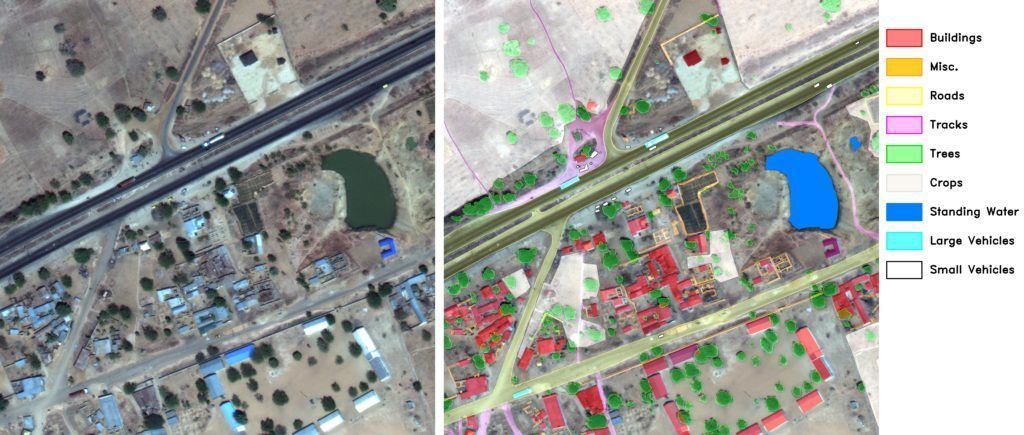

Mais precisamente, a segmentação semântica de imagens é a tarefa de rotular cada pixel da imagem em um conjunto predefinido de classes. Por exemplo, vários objetos como carros, árvores, pessoas, sinais de trânsito etc. podem ser usados como classes para segmentação semântica de imagens. Portanto, a tarefa é pegar uma imagem (RGB ou escala de cinza) e produzir uma matriz W x H x 1, onde W e H representam a largura e a altura da imagem, respectivamente. Cada célula nesta matriz conteria os IDs de classe previstos para cada pixel na imagem.

No Deep learning, expressamos rótulos de classe categórica como vetores codificados one-hot. Da mesma forma, na segmentação semântica, podemos expressar a matriz de saída usando um esquema de codificação one-hot essencialmente criando um canal para cada rótulo de classe e marcando as células por 1 que contêm o pixel da classe correspondente e marcando as células restantes por 0.

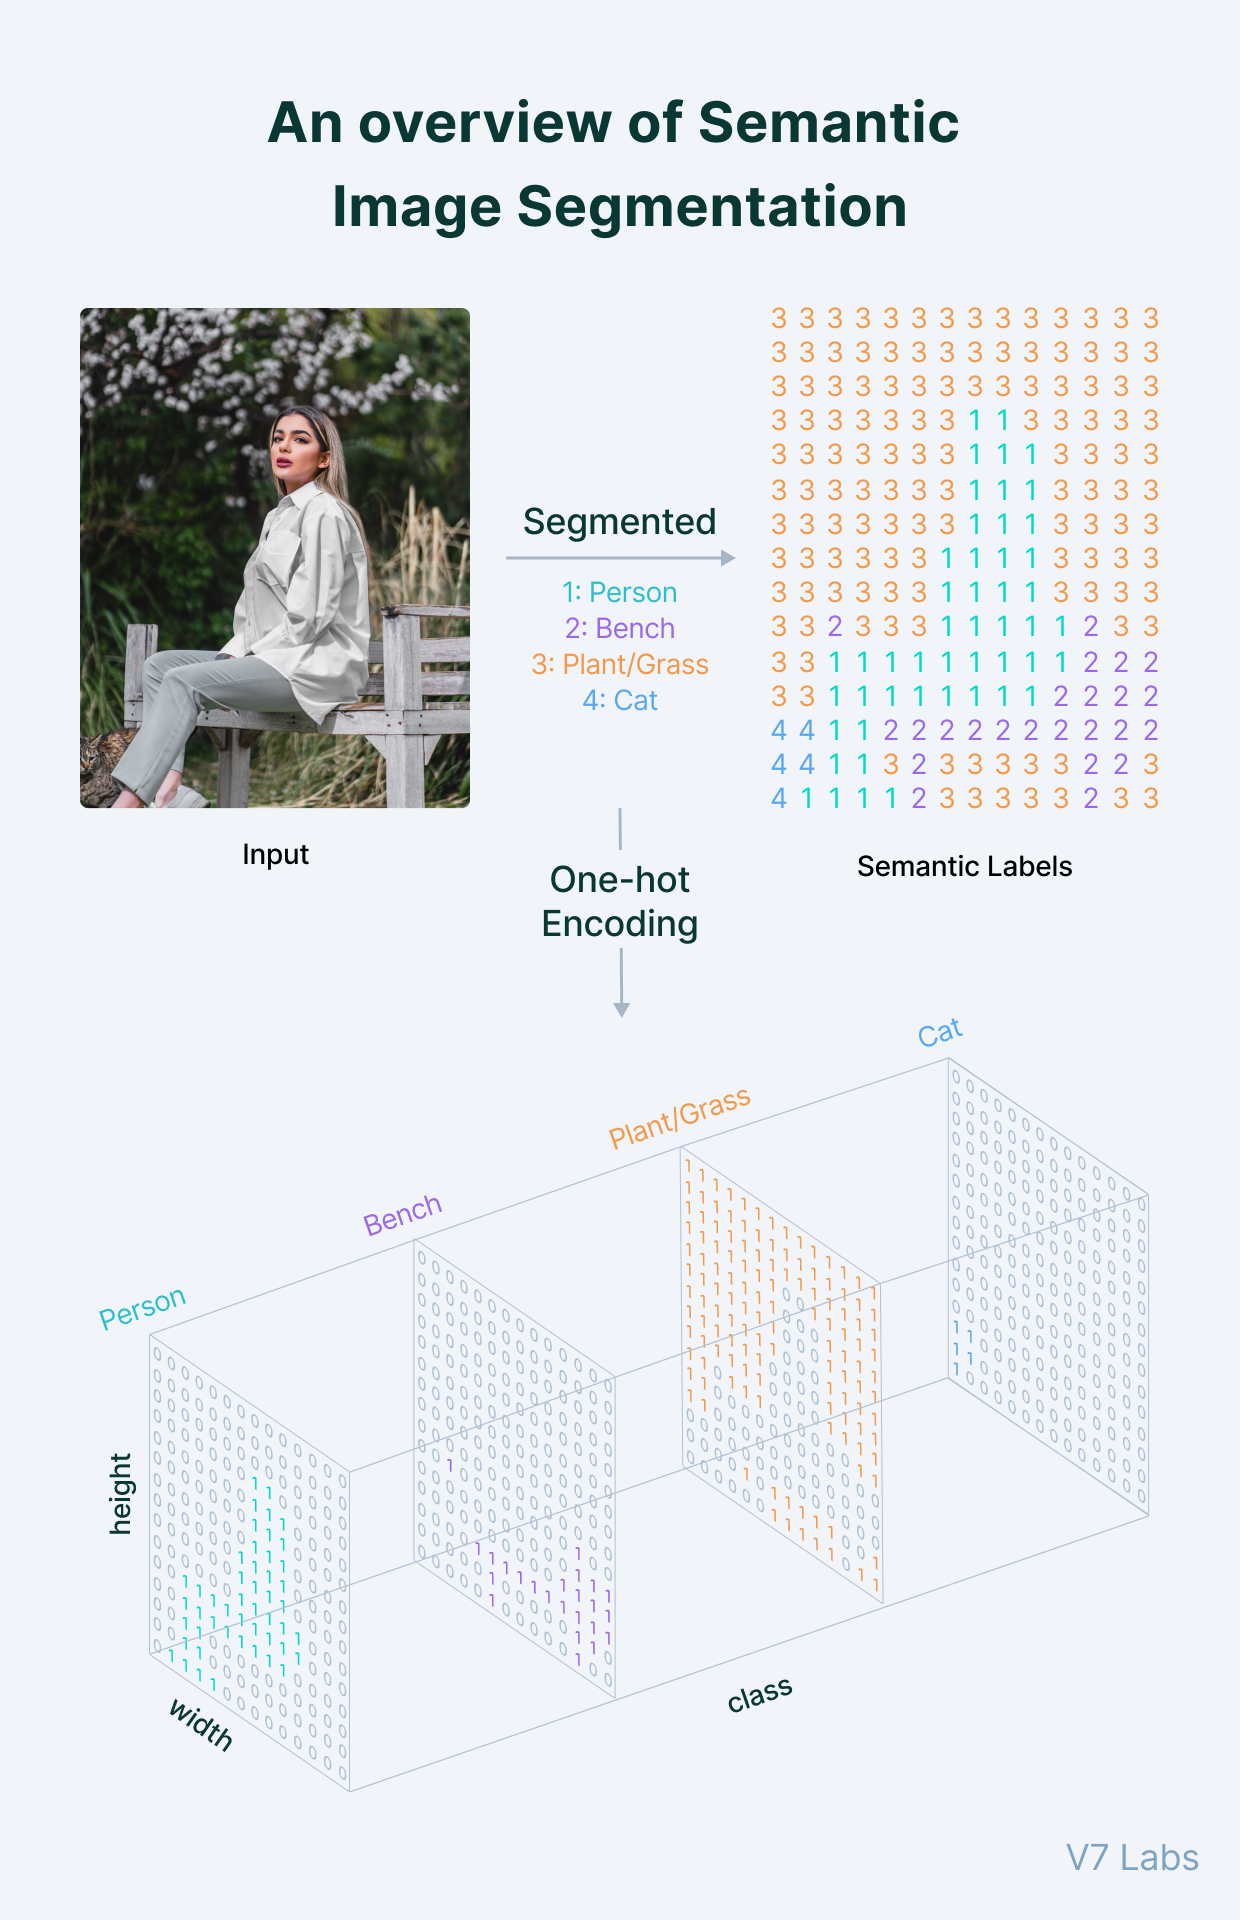

Como outras tarefas de visão computacional, usar uma CNN para segmentação semântica seria a escolha óbvia. Ao usar CNN para segmentação semântica, a saída seria uma imagem com a mesma resolução da entrada, diferentemente de um vetor de comprimento fixo no caso de classificação de imagens.
A arquitetura geral dos modelos contém uma série de camadas convolucionais juntamente com camadas convolucionais agrupadas ou strided para downsampling. Para melhorar o modelo, também são utilizadas ativações não lineares e camadas de normalização em lote.
As camadas iniciais em uma rede neural convolucional aprendem recursos de baixo nível, como linhas, bordas, cores, etc., e as camadas mais profundas aprendem recursos de alto nível, como rostos ou objetos, etc.

Agora que obtivemos esse tensor de baixa resolução, de alguma forma temos que aumentar sua resolução até a imagem original para cumprir a tarefa de segmentação semântica. Alimentamos este mapa de recursos de baixa resolução para camadas de upsampling seguidas por mais camadas de convolução para criar mapas de recursos de resolução mais alta. À medida que aumentamos a resolução, diminuímos simultaneamente o número de canais nos mapas de recursos. Este tipo de arquitetura é conhecido como arquitetura codificador-decodificador. A fase de downsampling é conhecida como codificador e a fase de upsampling é chamada de decodificador.

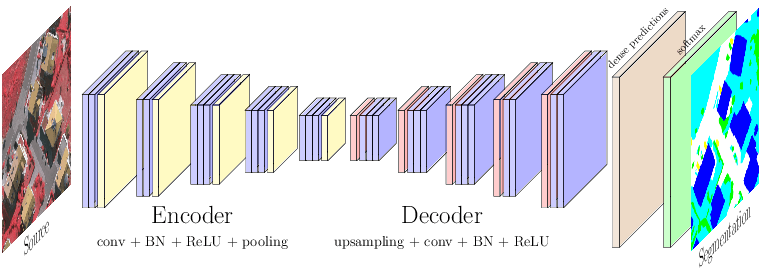

## U-Net

U-Net é uma arquitetura desenvolvida por Olaf Ronneberger et al. para Segmentação de Imagens Biomédicas em 2015 na Universidade de Freiburg, Alemanha. É uma das abordagens mais popularmente usadas em qualquer tarefa de segmentação semântica hoje. É uma rede neural totalmente convolucional projetada para aprender com menos amostras de treinamento. É uma melhoria em relação ao FCN existente – “Redes totalmente convolucionais para segmentação semântica” desenvolvido por Jonathan Long et al. em 2014).

U-Net é uma arquitetura de rede codificador-decodificador em forma de U, que consiste em quatro blocos codificadores e quatro blocos decodificadores conectados por meio de uma ponte. A rede do codificador (caminho de contração) metade das dimensões espaciais e o dobro do número de filtros (canais de recursos) em cada bloco do codificador. Da mesma forma, a rede de decodificadores dobra as dimensões espaciais e metade do número de canais de recursos.

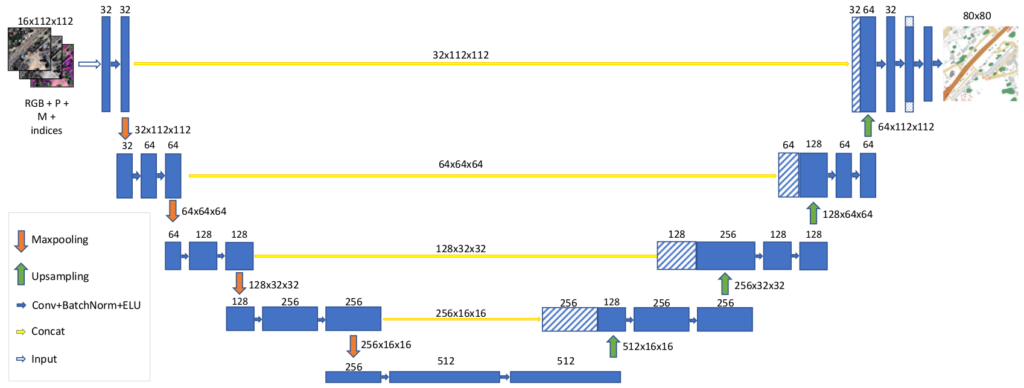

Codificador

O codificador atua como o extrator de recursos e aprende uma representação abstrata da imagem de entrada por meio de uma sequência de blocos do codificador. Cada bloco do codificador consiste em duas convoluções 3x3, onde cada convolução é seguida por uma função de ativação ReLU (Rectified Linear Unit). A função de ativação ReLU introduz não linearidade na rede, o que ajuda na melhor generalização dos dados de treinamento. A saída do ReLU atua como uma conexão de salto para o bloco decodificador correspondente.
Em seguida, segue um 2x2 max-pooling, onde as dimensões espaciais (altura e largura) dos mapas de recursos são reduzidas pela metade. Isso reduz o custo computacional diminuindo o número de parâmetros treináveis.

As skips connection fornecem informações adicionais que ajudam o decodificador a gerar melhores recursos semânticos. Eles também atuam como uma conexão de atalho que ajuda o fluxo indireto de gradientes para as camadas anteriores sem qualquer degradação. Em termos simples, podemos dizer que a skip connection ajuda no melhor fluxo de gradiente enquanto backpropagation, o que por sua vez ajuda a rede a aprender uma melhor representação.




Decodificador

O decodificador é usado para pegar a representação abstrata e gerar uma máscara de segmentação semântica. O bloco decodificador começa com uma convolução de transposição 2x2. Em seguida, ele é concatenado com o mapa de recursos da skip connection correspondente do bloco do codificador. Essas skips connections fornecem recursos de camadas anteriores que às vezes são perdidos devido à profundidade da rede. Depois disso, são utilizadas duas convoluções 3x3, onde cada convolução é seguida por uma função de ativação ReLU.
A saída do último decodificador passa por uma convolução 1x1 com ativação sigmóide. A função de ativação sigmóide fornece a máscara de segmentação que representa a classificação pixel a pixel.

# Usando modelos pré-treinados para segmentação de construções

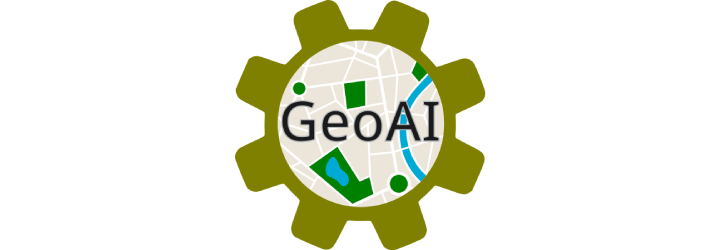

A biblioteca GeoAI é um pacote poderoso em Python que integra Inteligência Artificial à análise e visualização de dados geoespaciais. Projetada para facilitar o processamento, análise e visualização de dados como imagens de satélite, nuvens de pontos LiDAR e dados vetoriais, a GeoAI oferece interfaces intuitivas para aplicar modelos avançados de aprendizado de máquina. Entre seus principais recursos estão a visualização interativa de dados geoespaciais, ferramentas de preparação e processamento de dados, segmentação de imagens com integração ao Segment Anything Model (SAM) da Meta, classificação de imagens com modelos pré-treinados e capacidades adicionais como análise de terreno e detecção de objetos em imagens aéreas e de satélite.

Vamos utilizar os modelos pré-treinados da biblioteca GeoAI em uma imagen NAIP de alta resolução:

In [ ]:
!pip install geoai-py

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.6/269.6 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.5/122.5 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 603.9/603.9 kB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 142.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 882.2/882.2 kB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 130.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.2/62.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 605.3/605.3 kB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 147.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install ipysheet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 4.2 MB/s eta 0:00:00


Depois de instalar as bibliotecas, vamos importa-las e criar um mapa interativo para visualização:

In [ ]:
import geoai

In [ ]:
import leafmap
from geoai.download import (
    download_naip,
    download_overture_buildings,
    extract_building_stats,
)
import geopandas as gpd

Vamos selecionar nossa área de interesse a partir de um shapefile:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Link para download:https://drive.google.com/drive/folders/18Xdo1PRVt4D6oksz8skB6SybQSlgBDWk?usp=sharing

In [ ]:
aoi = gpd.read_file('/content/drive/MyDrive/Datasets/GeoAI_review/AOI.shp')

Com o boundbox da área vamos baixar a imagem NAIP:

In [ ]:
bbox = tuple(aoi.total_bounds)

In [ ]:
# Download NAIP imagery for the specified region
downloaded_files = download_naip(
    bbox=bbox,
    output_dir="naip_data",
    max_items=3,
    # year=2020,
)

print(f"Downloaded {len(downloaded_files)} files.")

Found 3 NAIP items.


m_3611547_nw_11_060_20220703.tif: 100%|██████████| 278M/278M [01:23<00:00, 3.48MiB/s]


Successfully saved to naip_data/m_3611547_nw_11_060_20220703.tif


m_3611547_ne_11_060_20220703.tif: 100%|██████████| 275M/275M [01:21<00:00, 3.53MiB/s]


Successfully saved to naip_data/m_3611547_ne_11_060_20220703.tif


m_3611547_sw_11_060_20220611.tif: 100%|██████████| 359M/359M [02:04<00:00, 3.03MiB/s]

Successfully saved to naip_data/m_3611547_sw_11_060_20220611.tif
Downloaded 3 files.


Como a área é grande, o donwload foi dividido em três imagens. Precisamos uni-las.

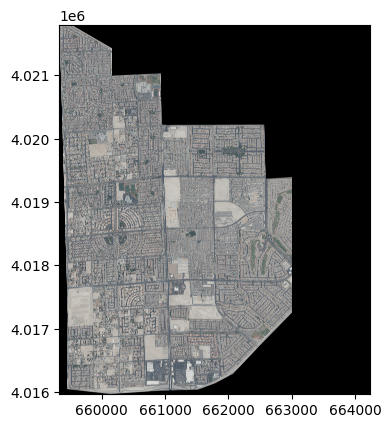

Mosaic created and clipped successfully.


In [ ]:
import rasterio
from rasterio.merge import merge
from rasterio.plot import show
import numpy as np
import matplotlib.pyplot as plt
import os

mosaic_files = []
for file in downloaded_files:
    mosaic_files.append(rasterio.open(file))

mosaic, out_trans = merge(mosaic_files)

out_meta = mosaic_files[0].meta.copy()
out_meta.update(
    {"driver": "GTiff",
     "height": mosaic.shape[1],
     "width": mosaic.shape[2],
     "transform": out_trans,
     "crs": mosaic_files[0].crs}
)

output_mosaic_file = "naip_mosaic.tif"
with rasterio.open(output_mosaic_file, "w", **out_meta) as dest:
    dest.write(mosaic)


with rasterio.open(output_mosaic_file) as src:
    aoi = aoi.to_crs(src.crs)
    out_image, out_transform = rasterio.mask.mask(src, aoi.geometry, crop=True)
    out_image = out_image[0:3]
    out_meta = src.meta

    out_meta.update({"driver": "GTiff",
                     "height": out_image.shape[1],
                     "width": out_image.shape[2],
                     "count": out_image.shape[0],
                     "transform": out_transform})

    with rasterio.open("clipped_naip_mosaic.tif", "w", **out_meta) as dest:
        dest.write(out_image)

with rasterio.open("clipped_naip_mosaic.tif") as src:
    show(src)

print("Mosaic created and clipped successfully.")

Então podemos instanciar o modelo pré-treinado.

In [ ]:
extractor = geoai.BuildingFootprintExtractor()

Model path not specified, downloading from Hugging Face...


building_footprints_usa.pth:   0%|          | 0.00/176M [00:00<?, ?B/s]

Model downloaded to: /root/.cache/huggingface/hub/models--giswqs--geoai/snapshots/75788bf6253e967a91b9576b1620949a3b939820/building_footprints_usa.pth
Model loaded successfully


Agroa aplicamos o modelo em nossa imagem:

In [ ]:
mask_path = extractor.save_masks_as_geotiff(
    raster_path='clipped_naip_mosaic.tif',
    output_path="building_masks.tif",
    confidence_threshold=0.5,
    mask_threshold=0.5,
)

Processing masks with parameters:
- Confidence threshold: 0.5
- Chip size: (512, 512)
- Mask threshold: 0.5
Dataset initialized with 26 rows and 22 columns of chips
Image dimensions: 8177 x 9730 pixels
Chip size: 512 x 512 pixels
Overlap: 25.0% (stride_x=384, stride_y=384)
CRS: EPSG:26911
Processing raster with 143 batches


100%|██████████| 143/143 [01:24<00:00,  1.69it/s]


Object masks saved to building_masks.tif


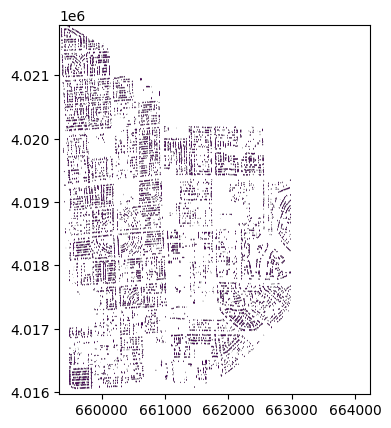

In [ ]:
# prompt: visualize building mask image with rasterio

with rasterio.open(mask_path) as src:
    show(src)


O modelo gera uma imagem TIFF como resultado, vamos converter esse resultado para um arquivo vetorial:

In [ ]:
gdf = extractor.masks_to_vector(
    mask_path=mask_path,
    output_path="building_masks.geojson",
    simplify_tolerance=1.0,
)

Converting mask to GeoJSON with parameters:
- Mask threshold: 0.5
- Min object area: 100
- Max object area: None
- Simplify tolerance: 1.0
- NMS IoU threshold: 0.5
- Regularize objects: True
- Angle threshold: 15° from 90°
- Rectangularity threshold: 70.0%
Mask dimensions: (9730, 8177)
Mask value range: 0 to 255
Found 6572 potential objects


100%|██████████| 6572/6572 [12:56<00:00,  8.46it/s]


Created 5285 valid polygons


Para regularizar os formatos dos poligonos podemos usar esta função:

In [ ]:
gdf_regularized = extractor.regularize_buildings(
    gdf=gdf,
    min_area=100,
    angle_threshold=15,
    orthogonality_threshold=0.3,
    rectangularity_threshold=0.7,
)

Regularizing 5285 objects...
- Angle threshold: 15° from 90°
- Min orthogonality: 30.0% of angles
- Min rectangularity: 70.0% of bounding box area


100%|██████████| 5285/5285 [00:03<00:00, 1640.14it/s]

Regularization completed:
- Total objects: 5285
- Rectangular objects: 4820 (91.2%)
- Other regularized objects: 0 (0.0%)
- Unmodified objects: 465 (8.8%)


Por fim visualizamos os resultados no mapa interativo:

In [ ]:
geoai.view_vector_interactive(
    gdf, column="confidence", layer_name="Building", tiles="Satellite"
)

In [ ]:
m = leafmap.Map()
m.add_raster("/content/clipped_naip_mosaic.tif", layer_name="NAIP")
m.add_gdf(gdf, layer_name="Buildings")
m

Map(center=[36.301361, -115.19817], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title'…